In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# Define file paths and a friendly name for each model
file_paths = {
    "Jina with Description": "/home/chb3333/yulab/chb3333/gem-patho/models/gene_name_seqs/cna_cancertype_polyphen_description_models/gene_name_polyphen_sum/jina_polyphen/folds_metrics.csv",
    "Jina with only Cancer Types": "/home/chb3333/yulab/chb3333/gem-patho/models/gene_name_seqs/cna_cancertype_polyphen_models/gene_name_polyphen_sum/jina_polyphen/folds_metrics.csv"}


In [7]:
results = {}

In [8]:
# Loop over each file/model
for model_name, csv_path in file_paths.items():
    # Read the CSV file
    df = pd.read_csv(csv_path)
    
    # Extract the c-index column of interest; here we use 'test_cindex'
    c_indices = df["test_cindex"]
    
    # Compute mean and standard deviation
    cindex_mean = c_indices.mean()
    cindex_std = c_indices.std()
    
    # Compute 95% confidence interval (CI) using 1.96 * (std / sqrt(n))
    # If you prefer standard error bars, just use cindex_std
    n = len(c_indices)
    cindex_sem = cindex_std / np.sqrt(n)
    ci = 1.96 * cindex_sem
    
    # Store in the dictionary
    results[model_name] = {
        "mean": cindex_mean,
        "std": cindex_std,
        "sem": cindex_sem,
        "ci": ci
    }


In [9]:

# Prepare data for plotting
model_names = list(results.keys())
means = [results[name]["mean"] for name in model_names]
# You can switch the error bars to "std", "sem", or "ci" depending on preference
errors = [results[name]["std"] for name in model_names]


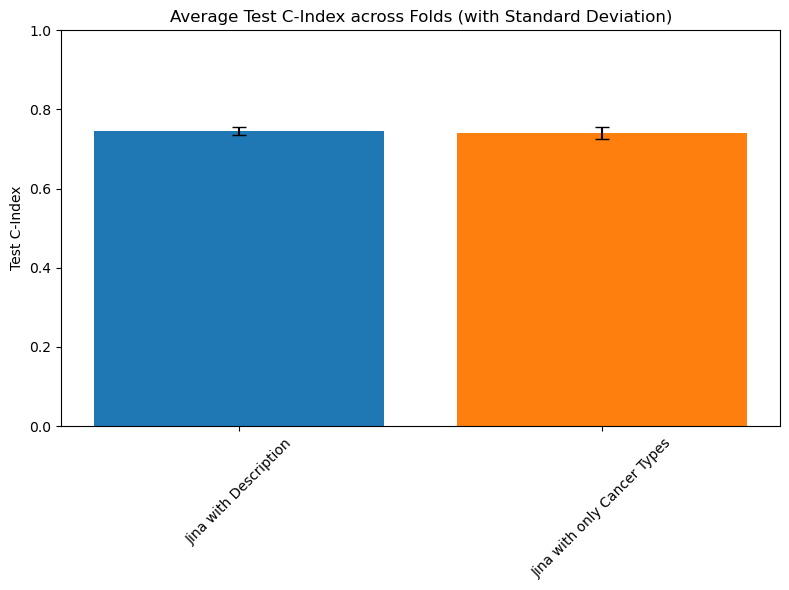

Jina with Description: mean=0.746, std=0.009, 95% CI=±0.006
Jina with only Cancer Types: mean=0.741, std=0.015, 95% CI=±0.009


In [10]:
# Create bar plot
plt.figure(figsize=(8, 6))
bars = plt.bar(model_names, means, yerr=errors, capsize=5, color=["#1f77b4","#ff7f0e","#2ca02c","#d62728"])

plt.ylabel("Test C-Index")
plt.title("Average Test C-Index across Folds (with Standard Deviation)")
plt.ylim(0, 1)  # Adjust if needed based on your c-index range
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Print numerical results
for model_name, stats in results.items():
    print(f"{model_name}: mean={stats['mean']:.3f}, std={stats['std']:.3f}, 95% CI=±{stats['ci']:.3f}")